In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [3]:
df =pd.read_csv('housing.csv')
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


#### 1. Univariate prediciton and comparing evaluations    

In [21]:
# Split data
X = df[['median_income']]
y = df['median_house_value']
x_train, x_test, y_train, y_test  = train_test_split(X,y, test_size=.2, random_state=42) 

In [22]:
# choosing a model, fit it into the model 
model = LinearRegression()
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.45885918903846656

In [23]:
# analyze intercepts and coeefficent 
intercept = model.intercept_
coeff = model.coef_[0]
print(f"Intercept: {intercept:.2f}")
print(f"Coefficent: {coeff:.2f}")

Intercept: 44459.73
Coefficent: 41933.85


In [25]:
# predicitons 
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [28]:
# prediction evaluation
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

train_r2 = r2_score(y_train,train_pred)
test_r2 = r2_score(y_test,test_pred)

print(train_rmse)
print(test_rmse)

print(train_r2)
print(test_r2)

83614.87409655548
84209.01241414454
0.4769927345820525
0.45885918903846656


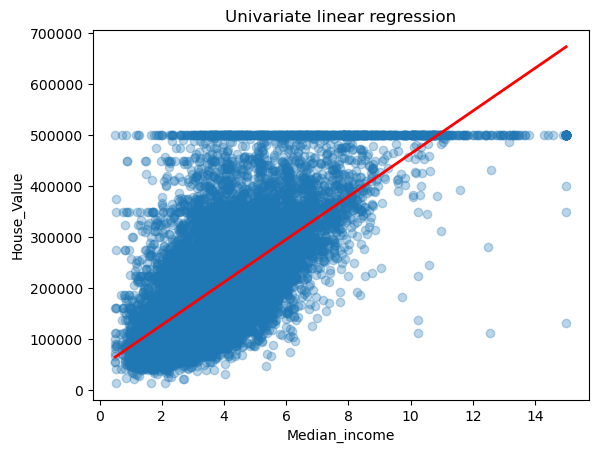

In [34]:
# regression plot
plt.scatter(x_train, y_train, alpha=.3)
x_sorted = x_train.sort_values('median_income')
y_sorted = model.predict(x_sorted)

plt.plot(
    x_sorted,
    y_sorted,
    color='red',
    linewidth=2
)
plt.xlabel('Median_income')
plt.ylabel('House_Value')
plt.title('Univariate linear regression');

#### 2. Multivariate prediciton and comparing evaluations    

In [ ]:
df.dropna()

In [40]:
# Encode Categroical data 

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['ocean_proximity'] = encoder.fit_transform(df['ocean_proximity'])

In [41]:
# Split data
X2 = df.drop('median_house_value' , axis=1)
y2 = df['median_house_value']
x2_train, x2_test, y2_train, y2_test  = train_test_split(X2,y2, test_size=.2, random_state=42) 

In [48]:
# standardize features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x2_train = scaler.fit_transform(x2_train)
x2_test = scaler.fit_transform(x2_test)

In [53]:
# choosing a model, fit it into the model 
model2 = LinearRegression()
model2.fit(x2_train, y2_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
# feature importance 
coefficients = pd.DataFrame({
    'feature': df.columns[df.columns != 'median_house_value'],
    'coefficient':model2.coef_
})

coefficients['Absolute'] = coefficients['coefficient'].abs()

coefficients.sort_values('Absolute', ascending=False, inplace=True)
print(coefficients)

              feature   coefficient      Absolute
1            latitude -90946.062711  90946.062711
0           longitude -85854.947241  85854.947241
7       median_income  77144.101642  77144.101642
4      total_bedrooms  48767.606710  48767.606710
5          population -43884.168524  43884.168524
3         total_rooms -17693.234053  17693.234053
6          households  17601.314951  17601.314951
2  housing_median_age  14924.306551  14924.306551
8     ocean_proximity   -451.520152    451.520152


In [61]:
# predicitons 
train_pred2 = model.predict(x2_train)
test_pred2 = model.predict(x2_test)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# prediction evaluation
train_rmse2 = np.sqrt(mean_squared_error(y2_train, train_pred2))
test_rmse2 = np.sqrt(mean_squared_error(y2_test, test_pred2))

train_r22 = r2_score(y2_train,train_pred2)
test_r22 = r2_score(y2_test,test_pred2)

print(train_rmse2)
print(test_rmse2)

print(train_r22)
print(test_r22)

In [62]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64